In [83]:
# ================================
# Inicio de Proyecto: Análisis de Churn en Telecomunicaciones
# ================================
#  Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import kagglehub

# Importar el dataset desde Kaggle
#  Download latest version
path = kagglehub.dataset_download("abbas829/telecom-customer-churn-feature-engineering-dataset")

print("Path to dataset files:", path)
import pandas as pd
df = pd.read_csv(path + "/telecom_customer_churn_feature_engineering.csv")
print(df.shape) 
print(df.head())    


Path to dataset files: C:\Users\victo\.cache\kagglehub\datasets\abbas829\telecom-customer-churn-feature-engineering-dataset\versions\1
(1200, 15)
   customer_id signup_date  age  gender        city education_level  \
0        10001  2019-01-01   65    Male      Multan        Bachelor   
1        10002  2019-01-02   22  Female    Peshawar          Master   
2        10003  2019-01-03   43    Male  Gujranwala       Secondary   
3        10004  2019-01-04   21    Male      Lahore       Secondary   
4        10005  2019-01-05   37  Female   Hyderabad         Primary   

  employment_status  monthly_income  monthly_bill  internet_usage_gb  \
0          Employed         57643.0       10049.0                5.8   
1          Employed         18207.0        2752.0               11.9   
2          Employed         13075.0        3155.0               40.0   
3          Employed         38890.0        5859.0                8.5   
4          Employed         17475.0        5106.0                3.

In [84]:
# ================================
# Inicio de Proceso de EDA
# ================================

# 1. Información general del dataset
print("Dimensiones:", df.shape)        # filas y columnas
print("Columnas:", df.columns.tolist()) # nombres de columnas
df.info()                               # tipos de datos y nulos

# 2. Estadísticas descriptivas
df.describe(include='all')              # resumen numérico y categórico

# 3. Distribución de la variable objetivo (churn)
print("\nDistribución de churn:")
print(df['churn'].value_counts())

# 4. Exploración de variables categóricas (automático)
categorical_cols = df.select_dtypes(include='object').columns
print("\nColumnas categóricas detectadas:", categorical_cols.tolist())

for col in categorical_cols:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts())

# 5. Exploración de variables numéricas (automático)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
print("\nColumnas numéricas detectadas:", numeric_cols.tolist())

for col in numeric_cols:
    print(f"\nResumen de {col}:")
    print(df[col].describe())

# 6. Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# 7. Duplicados
print("\nNúmero de filas duplicadas:", df.duplicated().sum())


Dimensiones: (1200, 15)
Columnas: ['customer_id', 'signup_date', 'age', 'gender', 'city', 'education_level', 'employment_status', 'monthly_income', 'monthly_bill', 'internet_usage_gb', 'call_minutes', 'contract_type', 'support_tickets', 'customer_feedback', 'churn']
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   str    
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   str    
 4   city               1200 non-null   str    
 5   education_level    1200 non-null   str    
 6   employment_status  1200 non-null   str    
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract

C:\Users\victo\AppData\Local\Temp\ipykernel_17860\1732766047.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [85]:
#================================
# Tipos de Relaciones entre Variebles
#================================

# Tasa de churn por tipo de contrato
print("=== Churn por tipo de contrato ===")
print(df.groupby('contract_type')['churn'].mean())

# Diferencia de ingresos y factura entre los que se van y los que se quedan
print("\n=== Promedios por grupo de churn ===")
print(df.groupby('churn')[['monthly_income', 'monthly_bill']].mean())

# Relación entre duración del contrato y churn
print("=== Factura promedio por tipo de contrato ===")
print(df.groupby('contract_type')['monthly_bill'].mean())

#Relación entre uso de internet y churn
print("=== Uso de internet por tipo de contrato ===")
print(df.groupby('contract_type')[['monthly_income','support_tickets','internet_usage_gb']].mean())

#Relacion entre tipo de contrato y feedback
print("=== Feedback por tipo de contrato ===")
print(df.groupby('contract_type')['customer_feedback'].value_counts())

=== Churn por tipo de contrato ===
contract_type
12-Month    0.176812
6-Month     0.220280
Monthly     0.520211
Name: churn, dtype: float64

=== Promedios por grupo de churn ===
       monthly_income  monthly_bill
churn                              
0        33563.182051   5405.491026
1        26685.450000   6930.233333
=== Factura promedio por tipo de contrato ===
contract_type
12-Month    5936.420290
6-Month     5813.846154
Monthly     6003.789104
Name: monthly_bill, dtype: float64
=== Uso de internet por tipo de contrato ===
               monthly_income  support_tickets  internet_usage_gb
contract_type                                                    
12-Month         30707.707246         1.200000          20.235072
6-Month          32359.961538         1.314685          19.922378
Monthly          30822.606327         1.128295          20.217926
=== Feedback por tipo de contrato ===
contract_type  customer_feedback                      
12-Month       Satisfied with the service  

In [86]:
# ================================
# Análisis de feedback de clientes
# ================================

# Distribución general de feedback
print(df['customer_feedback'].value_counts().head(20))

# Feedback por grupo de churn
print("\nFeedback en clientes que se quedaron:")
print(df[df['churn']==0]['customer_feedback'].value_counts().head(10))

print("\nFeedback en clientes que se fueron:")
print(df[df['churn']==1]['customer_feedback'].value_counts().head(10))


customer_feedback
Satisfied with the service                 134
Coverage is poor in my location            132
Too expensive compared to competitors      130
Billing issues occurred multiple times     128
Customer support was helpful               119
Happy with data packages                   116
Internet speed is very slow                116
Service is unreliable during peak hours    116
Frequent call drops in my area             108
Network quality is good overall            101
Name: count, dtype: int64

Feedback en clientes que se quedaron:
customer_feedback
Too expensive compared to competitors      90
Satisfied with the service                 88
Coverage is poor in my location            87
Billing issues occurred multiple times     82
Customer support was helpful               82
Service is unreliable during peak hours    80
Happy with data packages                   78
Frequent call drops in my area             72
Network quality is good overall            65
Internet speed 

In [87]:
#=====================================
#  Clasificación básica de feedback
#=====================================
positive_keywords = ["satisfied", "helpful", "happy", "good"]
negative_keywords = ["poor", "expensive", "issues", "slow", "unreliable", "drops"]

def classify_feedback(text):
    text = text.lower()
    if any(word in text for word in positive_keywords):
        return "Positive"
    elif any(word in text for word in negative_keywords):
        return "Negative"
    else:
        return "Neutral"

df['feedback_sentiment'] = df['customer_feedback'].apply(classify_feedback)
#=========================================
# Distribución de sentimientos por churn
#=========================================
print(df.groupby(['churn','feedback_sentiment']).size())


churn  feedback_sentiment
0      Negative              467
       Positive              313
1      Negative              263
       Positive              157
dtype: int64


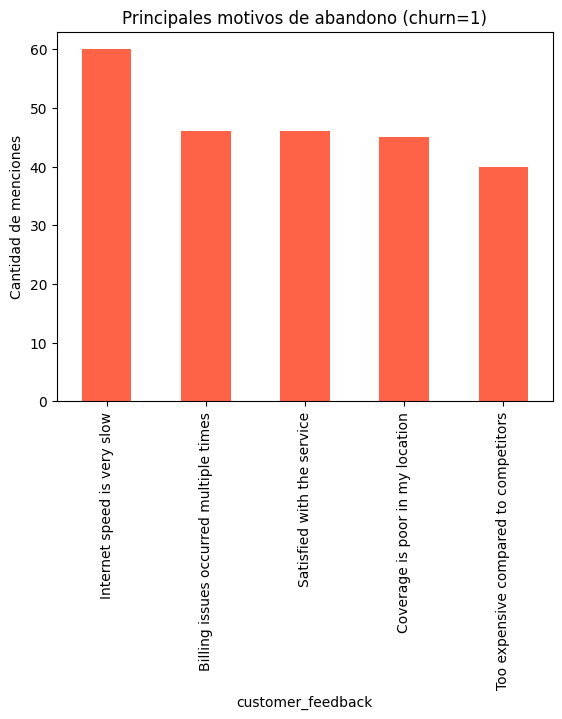

In [ ]:
#=======================================
# Distribución de feedback en clientes que se fueron en grafico
#=======================================
import matplotlib.pyplot as plt

feedback_counts = df[df['churn']==1]['customer_feedback'].value_counts().head(5)

feedback_counts.plot(kind='bar', color='tomato')
plt.title("Principales motivos de abandono (churn=1)")
plt.ylabel("Cantidad de menciones")
plt.savefig("churn_motivos.png", bbox_inches="tight", dpi=150)
plt.show()



In [89]:
#=======================================
# Preparación de datos para modelado de Regresión Logística
#=======================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data_model = df.copy()

# Codificación de variables categóricas
label_enc = LabelEncoder()
data_model['contract_type'] = label_enc.fit_transform(data_model['contract_type'])
data_model['feedback_sentiment'] = label_enc.fit_transform(data_model['feedback_sentiment'])

# Variables predictoras (X) y objetivo (y)
X = data_model[['contract_type', 'monthly_income', 'monthly_bill', 
                'internet_usage_gb', 'support_tickets', 'feedback_sentiment']]
y = data_model['churn']

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

#=======================================
# Modelo de Árbol de Decisión para churn
#=======================================
from sklearn.tree import DecisionTreeClassifier

# Crear y entrenar el modelo
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree.predict(X_test)

# Evaluación
print("Matriz de confusión (Árbol de Decisión):")
print(confusion_matrix(y_test, y_pred_tree))

print("\nReporte de clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_tree))

#=======================================
# Modelo de Random Forest para churn
#=======================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear y entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Evaluación
print("Matriz de confusión (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))



Matriz de confusión:
[[223   7]
 [ 25 105]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       230
           1       0.94      0.81      0.87       130

    accuracy                           0.91       360
   macro avg       0.92      0.89      0.90       360
weighted avg       0.91      0.91      0.91       360

Matriz de confusión (Árbol de Decisión):
[[229   1]
 [ 34  96]]

Reporte de clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       230
           1       0.99      0.74      0.85       130

    accuracy                           0.90       360
   macro avg       0.93      0.87      0.89       360
weighted avg       0.91      0.90      0.90       360

Matriz de confusión (Random Forest):
[[230   0]
 [ 14 116]]

Reporte de clasificación (Random Forest):
              precision    recall  f1-score   support

      

Matriz de confusión (Random Forest):
[[230   0]
 [ 14 116]]

Reporte de clasificación (Random Forest):
              precision    recall  f1-score   support

           0      0.943     1.000     0.970       230
           1      1.000     0.892     0.943       130

    accuracy                          0.961       360
   macro avg      0.971     0.946     0.957       360
weighted avg      0.963     0.961     0.961       360



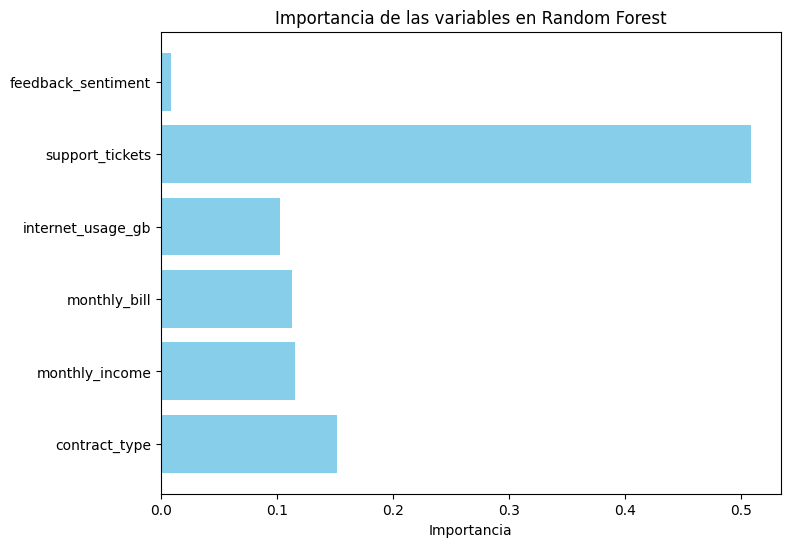

In [90]:
#=======================================
# Importancia de características en Random Forest y comparacion con Árbol de Decisión
#=======================================
from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de confusión (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, digits=3))  # más decimales y evita cortes

#=======================================
# Importancia de variables en Random Forest
#=======================================
import matplotlib.pyplot as plt

# Obtener importancia de cada variable
importances = rf.feature_importances_
features = X.columns

# Crear gráfico de barras
plt.figure(figsize=(8,6))
plt.barh(features, importances, color="skyblue")
plt.xlabel("Importancia")
plt.title("Importancia de las variables en Random Forest")
plt.show()



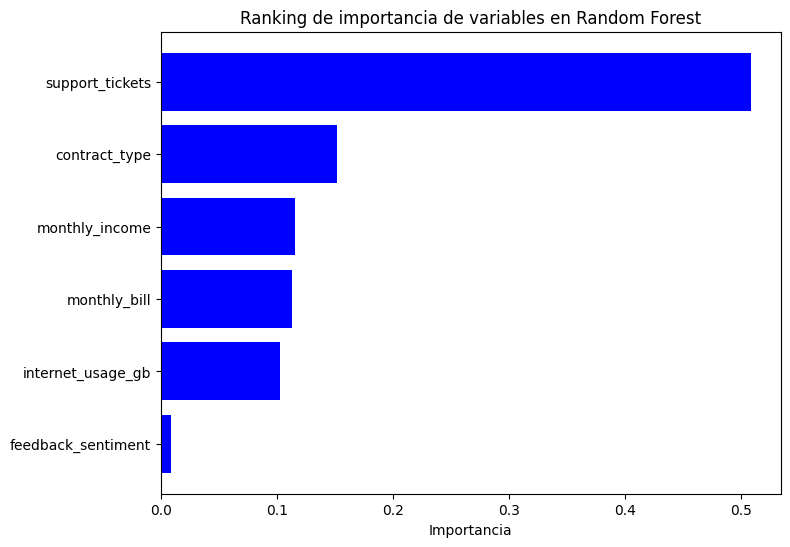

             Variable  Importancia
4     support_tickets     0.508577
0       contract_type     0.151942
1      monthly_income     0.115287
2        monthly_bill     0.113292
3   internet_usage_gb     0.102565
5  feedback_sentiment     0.008338


In [ ]:
#=======================================
# Ranking de importancia de variables en Random Forest
#=======================================
import pandas as pd
import matplotlib.pyplot as plt

# Crear DataFrame con variables e importancia
importances = rf.feature_importances_
features = X.columns
df_importances = pd.DataFrame({"Variable": features, "Importancia": importances})

# Ordenar de mayor a menor
df_importances = df_importances.sort_values(by="Importancia", ascending=True)

# Gráfico ordenado
plt.figure(figsize=(8,6))
plt.barh(df_importances["Variable"], df_importances["Importancia"], color="blue")
plt.xlabel("Importancia")
plt.title("Ranking de importancia de variables en Random Forest")
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()

# Mostrar tabla ordenada
print(df_importances.sort_values(by="Importancia", ascending=False))


## Conclusions and Recommendations
====================

- **Model performance:** The Random Forest model achieved an accuracy of 96%, outperforming Logistic Regression (91%) and Decision Tree (90%).  
- **Key insight:** The number of support tickets is the most influential variable (≈0.51), followed by contract type and billing-related features.  
- **Business implications:** Customers with frequent support requests are at the highest risk of churn. Short-term contracts and high bills also increase the likelihood of leaving.  
- **Recommended actions:**
  - Implement proactive monitoring of customers with multiple support tickets and provide priority assistance.
  - Encourage long-term contracts by offering discounts or loyalty benefits.
  - Design flexible billing plans for price-sensitive customers to reduce churn risk.
  - Improve customer experience in support interactions to prevent dissatisfaction from escalating into churn.

====================
## Conclusiones y Recomendaciones
====================

- **Rendimiento del modelo:** El modelo Random Forest alcanzó un 96% de exactitud, superando a la Regresión Logística (91%) y al Árbol de Decisión (90%).  
- **Insight clave:** La cantidad de tickets de soporte es la variable más influyente (≈0.51), seguida por el tipo de contrato y las características de facturación.  
- **Implicaciones de negocio:** Los clientes con múltiples reclamos de soporte tienen el mayor riesgo de churn. Los contratos de corto plazo y las facturas altas también aumentan la probabilidad de abandono.  
- **Acciones recomendadas:**
  - Implementar monitoreo proactivo de clientes con muchos tickets de soporte y brindarles asistencia prioritaria.
  - Incentivar contratos de largo plazo ofreciendo descuentos o beneficios de fidelización.
  - Diseñar planes de facturación flexibles para clientes sensibles al precio y así reducir el riesgo de churn.
  - Mejorar la experiencia en las interacciones de soporte para evitar que la insatisfacción escale hacia el abandono.

====================
